# Reachy System 2 — walkthrough notebook

| Section | Module | Role |
|--------|--------|------|
| **Setup** | — | — |
| **1 — Perception** | `reachy_system2.perception` | Pollen Vision `Perception` + SDK camera: RGB, depth-backed detections, `scene` text for the LLM. |
| **2 — Reasoning** | `reachy_system2.reasoning` | OpenAI vision: plan JSON (`generate_plan`) and later verification. |
| **3 — Executor** | `reachy_system2.executor` | Parse actions, **safe workspace** checks, dispatch to `reachy2_sdk` (`wait=True` by default). |
| **4 — Verification** | `reachy_system2.reasoning` | Multimodal **verify** with before/after images. |
| **5 — Orchestration** | `reachy_system2.main` | Optional `run_closed_loop` (creates its **own** `System2Perception` — stop the walkthrough instance first). |

## Setup 

- Ensures the repo root is on `sys.path` so `import reachy_system2` works from any kernel working directory.
- Loads **secrets and defaults** from `<repo>/.env`

In [2]:
from pathlib import Path
import os
import sys


def find_repo_root() -> Path:
    """Walk upward until we find `.git` or a reachy_pollen-style root."""
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
        if (parent / "reachy_system2").is_dir() and (parent / "README.md").exists():
            return parent
    return p


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")
print("REPO_ROOT =", REPO_ROOT)

REPO_ROOT = /home/nikolaraicevic/Workspace/Internal/Reachy_Pollen


## Setup — run parameters

These drive **Section 1** (labels for OWL-ViT / `Perception`) and **Section 2** (natural-language task for planning).

In [3]:
import os

HOST = os.environ.get("REACHY_HOST", "192.168.10.172")
LABELS = [s.strip() for s in os.environ.get("SYSTEM2_LABELS", "bowl,apple").split(",") if s.strip()]
TASK = os.environ.get("SYSTEM2_TASK", "Describe the scene and suggest a safe motion.")
SETTLING_S = float(os.environ.get("SETTLING_S", "0.75"))

print("HOST:", HOST)
print("LABELS:", LABELS)
print("TASK:", TASK)
print("SETTLING_S:", SETTLING_S)

HOST: 192.168.10.172
LABELS: ['tomato soup can', 'metal bowl']
TASK: Pick up the tomato soup can and place it into the metal bowl
SETTLING_S: 0.75


## Section 1 — Perception (`reachy_system2.perception`)

**What this does:** connects to Reachy, builds `System2Perception`, runs `set_tracked_objects()`, and `snapshot()` to get:
- **`rgb`**: left camera image,
- **`scene`**: text block of detected objects in **robot frame** with scores (fed to the LLM in Section 2).

In [4]:
from reachy2_sdk import ReachySDK

reachy = ReachySDK(HOST)
ic = reachy.is_connected() if callable(getattr(reachy, "is_connected", None)) else bool(reachy.is_connected)
assert ic, "Not connected — check REACHY_HOST and network."
assert reachy.cameras is not None and reachy.cameras.depth is not None, (
    "Depth camera required for Perception extrinsics (see greengrocer tutorial)."
)
print("Reachy connected; depth camera present.")

Local API version (1.0.21) is different from the robot's API version (1.0.19).
Some features may not work properly.
Please update the reachy2_core image on the robot to ensure compatibility, or downgrade your local reachy2_sdk package.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.



Reachy connected; depth camera present.


In [5]:
from reachy_system2.perception import System2Perception

perception = System2Perception(reachy)
perception.set_tracked_labels(LABELS)
perception.start(visualize=False)

rgb, scene = perception.snapshot(settling_s=SETTLING_S)
print(scene)
print("RGB shape:", rgb.shape, "dtype:", rgb.dtype)

/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Already connected to Reachy.
This Reachy is in REAL mode :
⚠️  Be careful, you're controlling the PHYSICAL Reachy.

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


DETECTED_OBJECTS (robot frame, meters; +Y = robot's left):

- tomato soup can: x=0.4199, y=-0.2308, z=-0.3266 detection_score=0.173 temporal_score=0.200
- metal bowl: x=0.4844, y=0.1460, z=-0.3538 detection_score=0.234 temporal_score=0.200
RGB shape: (720, 1280, 3) dtype: uint8


### Section 1 — optional: visualize the frame used above

Confirms the same `rgb` tensor you will pass into **Section 2** (planning) and later verification.

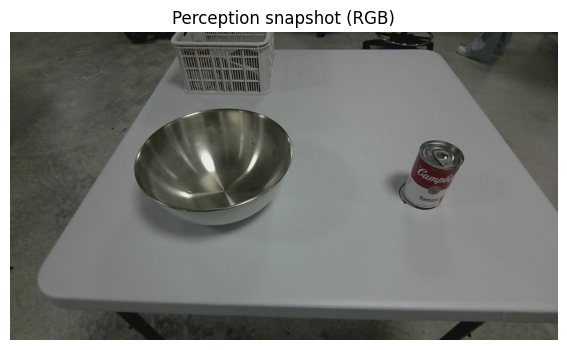

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [6]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 4))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title("Perception snapshot (RGB)")
    plt.show()
except Exception as e:
    print("matplotlib display skipped:", e)

## Section 2 — Reasoning (`reachy_system2.reasoning`)

**What this does:** calls OpenAI with **text + image** (`scene` + `rgb`) and returns a **JSON plan** (`subtasks` with structured `actions`).

### Quick OpenAI check

The next cell is a tiny `chat.completions` call (same stack as `ReasoningClient`). Ensure `OPENAI_API_KEY` is set in `.env` (loaded in Setup), then run it before the planning cells.


In [7]:
import os

from openai import OpenAI

_base = (os.environ.get("OPENAI_BASE_URL") or "").strip() or None
client = OpenAI(base_url=_base) if _base else OpenAI()

response = client.chat.completions.create(
    model=os.environ.get("OPENAI_MODEL", "gpt-4o"),
    messages=[
        {"role": "user", "content": "Write a one-sentence bedtime story about a unicorn."}
    ],
    max_tokens=80,
)
print(response.choices[0].message.content)


Under the shimmering glow of the moonlit forest, a gentle unicorn named Luna softly sang a lullaby to the stars, who twinkled back with dreams of magic and wonder.


In [8]:
import json

from reachy_system2.reasoning import ReasoningClient

reasoning = ReasoningClient()
plan = reasoning.generate_plan(TASK, scene, rgb)
print(json.dumps(plan, indent=2)[:8000])

{
  "subtasks": [
    {
      "description": "Approach the tomato soup can",
      "actions": [
        {
          "op": "r_arm_goto_pose",
          "xyz": [
            0.4199,
            -0.2308,
            -0.2266
          ],
          "rpy_deg": [
            0,
            0,
            0
          ],
          "duration": 3.0
        }
      ]
    },
    {
      "description": "Grasp the tomato soup can",
      "actions": [
        {
          "op": "r_arm_translate",
          "x": 0.0,
          "y": 0.0,
          "z": -0.1,
          "frame": "robot"
        },
        {
          "op": "r_gripper_goto",
          "position": 0,
          "duration": 2.0
        }
      ]
    },
    {
      "description": "Lift the tomato soup can",
      "actions": [
        {
          "op": "r_arm_translate",
          "x": 0.0,
          "y": 0.0,
          "z": 0.1,
          "frame": "robot"
        }
      ]
    },
    {
      "description": "Move to the metal bowl",
      "actio

## Section 3 — Executor (`reachy_system2.executor`)

**What this does:** `ActionExecutor` maps each JSON `action` (`op` + fields) to `reachy2_sdk` calls. Before Cartesian `goto`, translations are checked against the **safe workspace** box from `.env` / `config.py`.

Below: **validate** the first subtask, then **`dry_run=True`** so no real motion is sent (safe smoke test).

In [10]:
from reachy_system2.executor import ActionExecutor

executor = ActionExecutor(reachy)
sub0 = plan["subtasks"][0]

v = executor.validate_subtask_bounds(sub0)
print("validate_subtask_bounds:", v)

r = executor.run_subtask(sub0, wait=True, dry_run=False)
print("run_subtask (dry_run=True):", r)

validate_subtask_bounds: ExecutionResult(ok=True, message='all targets in workspace', out_of_workspace=False, rejected_xyz=None)
run_subtask (dry_run=True): ExecutionResult(ok=True, message='subtask complete', out_of_workspace=False, rejected_xyz=None)


## Section 4 — Verification (`verify_execution`)

**What this does:** after a subtask (here we only did a **dry_run**, so the scene may be unchanged), grab a **fresh snapshot**, then ask the model whether the subtask succeeded (`OK` / `FAILED`) and optionally return a **correction** JSON.

In the full loop (`run_closed_loop`), this runs after **real** motion with `rgb_before` / `rgb_after`.

In [11]:
import json

rgb_before = rgb
rgb2, scene2 = perception.snapshot(settling_s=SETTLING_S)

ver = reasoning.verify_execution(
    goal=TASK,
    subtask_description=sub0.get("description", ""),
    scene_after=scene2,
    rgb_after=rgb2,
    rgb_before=rgb_before,
)
print(json.dumps(ver, indent=2))

{
  "status": "OK",
  "correction": null
}


## Section 5 — Full closed loop (`run_closed_loop`)

**What this does:** `reachy_system2.main.run_closed_loop` wires **Perception → plan → validate → execute → verify** (and OOB replan / corrections) in one call. It instantiates a **new** `System2Perception`, so you must **`perception.stop()`** on the walkthrough instance first to avoid two trackers on the same robot.

- Use `dry_run=True` first.
- Use `confirm_steps=True` to approve each subtask on stdin when running from CLI; from the notebook you typically keep the loop commented and drive steps manually above.
- Run logs (including **token usage**) go under `reachy_system2/runs/<timestamp>/` when `SYSTEM2_LOG_RUNS=1` (see `run_tracker.py`).

In [ ]:
from reachy_system2.main import run_closed_loop

# Required before uncommenting run_closed_loop: release the Perception thread started in Section 1.
perception.stop()

# Optional: end-to-end loop (creates its own perception + optional RunTracker)
# run_closed_loop(
#     reachy=reachy,
#     task=TASK,
#     labels=LABELS,
#     settling_s=SETTLING_S,
#     confirm_steps=True,
#     dry_run=True,
#     log_runs=True,
#     robot_host=HOST,
# )

print("Walkthrough cells finished.")